<a href="https://colab.research.google.com/github/knc6/jarvis-tools-notebooks/blob/master/jarvis-tools-notebooks/Train_ALIGNNFF_Mlearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Train machine learning force-field with [ALIGNN](https://github.com/atomgptlab/alignn) for example Silicon dataset

# Table of contents

1. Install [ALIGNN](https://github.com/usnistgov/alignn)
2. Train a simple Silicon ALIGNN-FF,
3. Post-raining analysis, equation of state
4. ALIGNN-FF Ase Calculator: predict energy/forces, optimized strcture, EV curves and phonons
5. Run example MD (Melt-quench) to make amorphous Silicon
6. Phonon bandstructure for silicon
7. Scaling with number of atoms
8. Add ALIGNN-results to the JARVIS-Leaderboard

Author: Kamal Choudhary (kchoudh2@jhu.edu)

Install JARVIS-Leaderboard and ALIGNN

In [1]:
%%time
import os
# !pip install -q alignn
# !pip uninstall dgl -y
os.chdir('/content')
# Clone ALIGNN repo to get example folder
if not os.path.exists('alignn'):
   !git clone https://github.com/atomgptlab/alignn.git
os.chdir("alignn")

!git checkout develop
# !pip install -q --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.4/cu124/repo.html
!pip install -q -e .
# !uv pip install -q -e .
os.chdir('/content')

Cloning into 'alignn'...
remote: Enumerating objects: 5754, done.
remote: Counting objects: 100% (633/633), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 5754 (delta 567), reused 572 (delta 524), pack-reused 5121 (from 2)
Receiving objects: 100% (5754/5754), 155.37 MiB | 19.14 MiB/s, done.
Resolving deltas: 100% (3478/3478), done.
Branch 'develop' set up to track remote branch 'develop' from 'origin'.
Switched to a new branch 'develop'
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [4]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


Make sure torch cuda version is installed properly

In [5]:
import torch
torch.cuda.is_available()

True

In [6]:
%%time
import os
os.chdir('/content')

!rm -rf jarvis_leaderboard
# Clone JARVIS-Leaderboard repo to get example folder
if not os.path.exists('jarvis_leaderboard'):
  !git clone https://github.com/atomgptlab/jarvis_leaderboard.git
os.chdir('jarvis_leaderboard')
!pip install -q -e .
os.chdir('/content')

Cloning into 'jarvis_leaderboard'...
remote: Enumerating objects: 89613, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 89613 (delta 170), reused 151 (delta 151), pack-reused 89433 (from 2)
Receiving objects: 100% (89613/89613), 547.42 MiB | 29.57 MiB/s, done.
Resolving deltas: 100% (46540/46540), done.
Updating files: 100% (4695/4695), done.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
textblob 0.19.0 requires nltk>=3.9, but you have nltk 3.8.1 which is incompatible.
CPU times: user 2.22 s, sys: 299 ms, total: 2.52 s
Wall time: 49.7 s


## Runtime>> Restart session

In [1]:
import alignn

In [2]:
import requests

url = "https://ndownloader.figshare.com/files/46761919"
r = requests.get(url, allow_redirects=True)
open("mlearn_si_id_prop.json.zip", "wb").write(r.content)


370467

In [3]:
!ls

alignn	jarvis_leaderboard  mlearn_si_id_prop.json.zip	sample_data


In [4]:
!pwd

/content


Lets look at default alignn-ff model config, Restart session

In [5]:
import numpy
numpy.__version__

'2.0.2'

In [6]:
from alignn.ff.ff import default_path, AlignnAtomwiseCalculator
path = default_path()
print(path)

dir_path /root/.cache/atomgptlab/alignn_ff/v12.2.2024_dft_3d_307k


100%|██████████| 549k/549k [00:00<00:00, 974kiB/s]

/root/.cache/atomgptlab/alignn_ff/v12.2.2024_dft_3d_307k


In [7]:
# !ls /usr/local/lib/python3.11/site-packages/alignn/ff/v12.2.2024_dft_3d_307k

In [8]:
from jarvis.db.jsonutils import loadjson,dumpjson
import pprint
config=loadjson(path+'/config.json')
#pprint.pprint(config)

We are going to update n_train, n_val, n_test as per this dataset keeping evrything else fixed. These number are taken from jarvis-leaderboard


In [9]:
config['n_train']=214
config['n_val']=25
config['n_test']=25
config['cutoff']=5
config['model']['name']="alignn_atomwise_pure" #Not using DGL
config['neighbor_strategy']="pure_torch" #Not using DGL
config['epochs']=200

# config['compute_line_graph']=False
# config["model"]['alignn_layers']=0


dumpjson(data=config, filename='config_si_mlearn.json')



In [10]:
!unzip mlearn_si_id_prop.json.zip

Archive:  mlearn_si_id_prop.json.zip
  inflating: mlearn_si_id_prop.json  


In [11]:
import os
from jarvis.db.jsonutils import loadjson,dumpjson
!rm mlearn_si_id_prop.json
if not os.path.exists('DataDir'):
  os.makedirs('DataDir')
!unzip mlearn_si_id_prop.json.zip
!mv mlearn_si_id_prop.json DataDir/id_prop.json


Archive:  mlearn_si_id_prop.json.zip
  inflating: mlearn_si_id_prop.json  


Check input data format

The DataDir/id_prop.json contains arrays of dictionaries. Each dictionary has keys such as 'id', 'atoms', 'forces', 'total_energy'.


An example to convert a vasprun.xml to id_prop.json is available [here](https://gist.github.com/knc6/5513b21f5fd83a7943509ffdf5c3608b).

In [12]:
!ls

alignn		       DataDir		   mlearn_si_id_prop.json.zip
config_si_mlearn.json  jarvis_leaderboard  sample_data


In [13]:
from jarvis.db.jsonutils import loadjson
import pprint

d=loadjson('DataDir/id_prop.json')
# pprint.pprint(d[0])

In [14]:
!rm -rf sampletrain_data  sampleval_data sampletest_data

In [15]:
import alignn
alignn.__file__

In [16]:
import torch
torch.__version__

'2.10.0+cu128'

In [17]:
# # Only if you are using GPU based training
# !pip uninstall dgl -y
# !pip install --no-cache-dir dgl -f https://data.dgl.ai/wheels/torch-2.2/cu121/repo.html

In [18]:

%%time
!train_alignn.py --root_dir DataDir/ --config config_si_mlearn.json --output_dir OutputDir

/content/alignn/alignn/train.py:58: SyntaxWarning: invalid escape sequence '\ '
  / \  | |   |_ _/ ___| \ | | \ | |
fatal: not a git repository (or any of the parent directories): .git
world_size 1
root_dir DataDir/
len dataset 264
train_stress False
Using pure-torch LMDB dataset (no DGL).
MAX val: -4.5603584190625
MIN val: -5.4253234771875
MAD: 0.2771504487888568
Baseline MAE: 0.2861611033805039
data range -4.56655198359375 -5.4253234771875
line_graph True
100% 214/214 [00:01<00:00, 157.35it/s]
data range -4.5603584190625 -5.3883693821875
line_graph True
100% 25/25 [00:00<00:00, 182.87it/s]
data range -4.5603584190625 -5.3883693821875
line_graph True
100% 25/25 [00:00<00:00, 154.30it/s]
n_train: 214
n_val  : 25
n_test : 25
rank 0
world_size 1
config: {'version': 'af3ae5d1c5711ef9cad6cf930de78f30e6627382', 'dataset': 'user_data', 'target': 'target', 'atom_features': 'atomic_number', 'neighbor_strategy': 'pure_torch', 'id_tag': 'jid', 'dtype': 'float32', 'random_seed': 123, 'classificat

In [19]:
!ls OutputDir

best_model.pt	    ids_train_val_test.json	 sampleval_data_data_range
config.json	    last_model.pt		 Test_results.json
current_model.pt    mad				 Train_results.json
history_train.json  sampletest_data_data_range	 Val_results.json
history_val.json    sampletrain_data_data_range


In [20]:
# Example of loading pytorch model, not necessary if you are going to use ASE calculator later
from alignn.models.alignn_atomwise_pure import ALIGNNAtomWisePureConfig , ALIGNNAtomWisePure
import torch
from jarvis.db.jsonutils import loadjson
config=loadjson('OutputDir/config.json')
restart_model_path = 'OutputDir/best_model.pt'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config['model']['stresswise_weight'] = 0.01 #to enable stress calculation
tmp = ALIGNNAtomWisePureConfig(**config["model"])
model = ALIGNNAtomWisePure(tmp)
model.load_state_dict(torch.load(restart_model_path, map_location=device))
model = model.to(device)

In [21]:
# !wget https://figshare.com/ndownloader/files/40357663 -O mlearn.json.zip

In [22]:
from jarvis.core.atoms import Atoms
from alignn.ff.ff import AlignnAtomwiseCalculator, default_path, ev_curve
import pandas as pd
import numpy as np
import zipfile
import json
import os
import glob
from alignn.graphs import Graph
import matplotlib.pyplot as plt
from ase.stress import full_3x3_to_voigt_6_stress, voigt_6_to_full_3x3_stress
from alignn.graphs import radius_graph_jarvis
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
calc = AlignnAtomwiseCalculator(path='OutputDir',device=device, force_mult_batchsize=False)


def get_pred(atoms=None):
    atoms=atoms.ase_converter()
    atoms.calc=calc
    return atoms.get_potential_energy(),atoms.get_forces(),atoms.get_stress()

    # # g,lg=radius_graph_jarvis(atoms=atoms,cutoff=config['cutoff'])
    # g,lg=Graph.atom_dgl_multigraph(atoms=atoms,cutoff=config['cutoff'])
    # out = model([g.to(device),lg.to(device)])
    # #print('out',out,out.keys())
    # energy = out['out'].cpu().detach().numpy()*atoms.num_atoms
    # forces = out['grad'].cpu().detach().numpy()*atoms.num_atoms
    # stress = np.zeros((3,3)) #out["stresses"][:3].reshape(3, 3).detach().cpu().numpy()
    # return energy,forces,stress






df = pd.DataFrame(
    json.loads(
        zipfile.ZipFile("mlearn_si_id_prop.json.zip").read(
            "mlearn_si_id_prop.json"
        )
    )
)
print(df)
element="Si"
# print(df)
for i in glob.glob("/content/jarvis_leaderboard/jarvis_leaderboard/benchmarks/AI/MLFF/*energy*.zip"):
    if "mlearn" in i and element in i:
        fname_e = (
            "AI-MLFF-energy-"
            + i.split("/")[-1].split("_energy.json.zip")[0]
            + "-test-mae.csv"
        )
        fname_f = (
            "AI-MLFF-forces-"
            + i.split("/")[-1].split("_energy.json.zip")[0]
            + "-test-multimae.csv"
        )
        fname_s = (
            "AI-MLFF-stresses-"
            + i.split("/")[-1].split("_energy.json.zip")[0]
            + "-test-multimae.csv"
        )
        f_e = open(fname_e, "w")
        f_f = open(fname_f, "w")
        f_s = open(fname_s, "w")

        f_e.write("id,target,prediction\n")
        f_f.write("id,target,prediction\n")
        f_s.write("id,target,prediction\n")
        #voigt_6_to_full_3x3_stress
        print(i)
        dat = json.loads(
            zipfile.ZipFile(i).read(i.split("/")[-1].split(".zip")[0])
        )
        print(dat["test"])
        for key, val in dat["test"].items():
            entry = df[df["jid"] == key]
            atoms = Atoms.from_dict(entry.atoms.values[0])
            # print(key,val,df[df['jid']==key],atoms)
            # energy,forces=get_alignn_forces(atoms)
            energy, forces, stress = get_pred(atoms=atoms)
            # print(key, val, energy, atoms.num_atoms)
            line = key + "," + str(entry.total_energy.values[0]*atoms.num_atoms)+","+str(energy[0]) + "\n"
            print(line)
            f_e.write(line)
            line = (
                key
                + ","
                + str(";".join(map(str, np.array(entry.forces.values[0]).flatten())))
                +","
                + str(";".join(map(str, np.array(forces).flatten())))
                + "\n"
            )
            f_f.write(line)
            line = (
                key
                + ","
                + str(";".join(map(str, np.array(voigt_6_to_full_3x3_stress(entry.stresses.values[0])).flatten())))
                +","
                + str(";".join(map(str, np.array(voigt_6_to_full_3x3_stress(stress)).flatten())))
                + "\n"
            )
            f_s.write(line)
        f_e.close()
        f_f.close()
        f_s.close()
        zname = fname_e + ".zip"
        with zipfile.ZipFile(zname, "w") as myzip:
            myzip.write(fname_e)

        zname = fname_f + ".zip"
        with zipfile.ZipFile(zname, "w") as myzip:
            myzip.write(fname_f)

        zname = fname_s + ".zip"
        with zipfile.ZipFile(zname, "w") as myzip:
            myzip.write(fname_s)




        jid                                              atoms  total_energy  \
0      Si-1  {'lattice_mat': [[14.22366, 5.591921, 15.55731...     -4.690437   
1      Si-2  {'lattice_mat': [[14.390374, 2.309401, 14.7893...     -4.706461   
2      Si-3  {'lattice_mat': [[13.125139, 0.474114, 0.15710...     -4.779050   
3      Si-4  {'lattice_mat': [[14.457355, -2.049613, 13.272...     -4.668139   
4      Si-5  {'lattice_mat': [[14.727256, 2.798612, 5.54958...     -4.719795   
..      ...                                                ...           ...   
259  Si-235  {'lattice_mat': [[10.937456, 0.0, 0.0], [0.0, ...     -5.386575   
260  Si-236  {'lattice_mat': [[10.937456, 0.0, 0.0], [0.0, ...     -5.386575   
261  Si-237  {'lattice_mat': [[10.937456, 0.0, 0.0], [-1.31...     -5.331588   
262  Si-238  {'lattice_mat': [[10.937456, 0.0, 0.0], [0.0, ...     -5.331588   
263  Si-239  {'lattice_mat': [[10.937456, 0.0, 0.0], [0.0, ...     -5.331588   

                                       

/content/alignn/alignn/ff/calculators.py:319: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor(atoms.cell)


Si-215,-297.62773938,-296.53662

Si-216,-295.77170067,-293.82654

Si-217,-291.28958206,-292.62424

Si-218,-296.24088456,-294.12268

Si-219,-294.41361742,-293.99542

Si-220,-334.75283939,-335.19064

Si-221,-334.69215136,-336.1334

Si-222,-184.71808052,-185.09097

Si-223,-121.41180043,-123.25072

Si-224,-338.93899696,-338.46533

Si-225,-338.83557056,-337.82147

Si-226,-335.68901422,-335.7149

Si-227,-333.7064957,-333.39697

Si-228,-344.85564046,-344.2217

Si-229,-344.81108268,-344.22925

Si-230,-298.83222646,-299.19168

Si-231,-298.96501782,-299.66736

Si-232,-295.20943762,-295.85132

Si-233,-291.86293882,-293.22595

Si-234,-344.74080048,-343.8131

Si-235,-344.74080047,-343.8131

Si-236,-344.74080046,-343.8131

Si-237,-341.22165747,-341.40845

Si-238,-341.22165734,-341.40845

Si-239,-341.22165747,-341.40842



0.8178915527999903


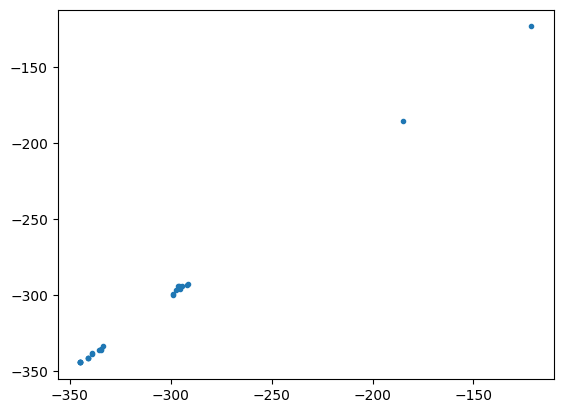

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
%matplotlib inline
df = pd.read_csv('AI-MLFF-energy-mlearn_Si-test-mae.csv')
plt.plot(df.target,df.prediction,'.')
print(mean_absolute_error(df.target,df.prediction))

0.08676093633453283


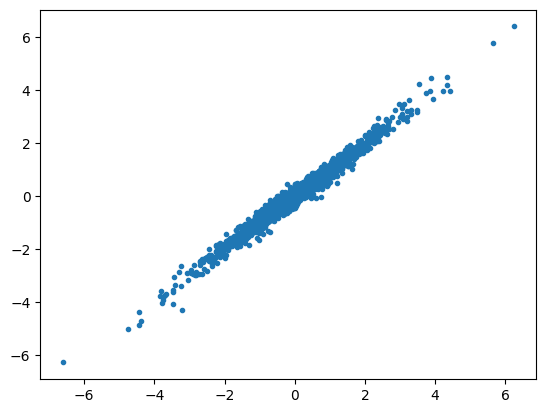

In [24]:
df = pd.read_csv('AI-MLFF-forces-mlearn_Si-test-multimae.csv.zip')
target = np.concatenate(df.target.apply(lambda x:np.array(x.split(';'),dtype='float')).values)
pred= np.concatenate(df.prediction.apply(lambda x:np.array(x.split(';'),dtype='float')).values)
print(mean_absolute_error(target,pred))
plt.plot(target,pred,'.')


In [25]:
# from ase.stress import voigt_6_to_full_3x3_stress

# df = pd.read_csv('AI-MLFF-stresses-mlearn_Si-test-multimae.csv.zip')
# target = np.concatenate(df.target.apply(lambda x:(np.array(x.split(';'),dtype='float')))).flatten()
# pred = 160*3*np.concatenate(df.prediction.apply(lambda x:(np.array(x.split(';'),dtype='float')))).flatten()
# print(mean_absolute_error(target,pred))
# plt.plot(target,pred,'.')


<>:24: SyntaxWarning: invalid escape sequence '\A'
<>:24: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_5368/2181163055.py:24: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Volume ($\AA^3$)')


Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699


100%|██████████| 40.8M/40.8M [00:03<00:00, 11.8MiB/s]


Loading the zipfile...
Loading completed.
kv 466.78239300359684


Text(0, 0.5, 'Total energy (eV)')

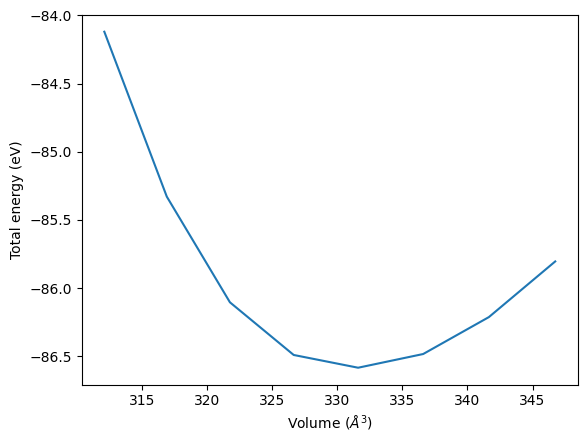

In [26]:
from ase.eos import EquationOfState
from ase.units import kJ
from jarvis.db.figshare import get_jid_data
from jarvis.core.atoms import Atoms
import matplotlib.pyplot as plt
%matplotlib inline
atoms=Atoms.from_dict(get_jid_data(jid='JVASP-1002',dataset='dft_3d')['atoms']).make_supercell([2,2,2])# get_conventional_atoms
#dx=np.arange(-0.1, 0.1, 0.01)
dx=np.arange(-0.02, 0.02, 0.005)
y = []
vol = []
for i in dx:
    s1 = atoms.strain_atoms(i)
    energy, forces, stress = get_pred(atoms=s1)
    y.append(energy[0])
    vol.append(s1.volume)
x = np.array(dx)
y = np.array(y)
eos = EquationOfState(vol, y, eos="murnaghan")
v0, e0, B = eos.fit()
kv = B / kJ * 1.0e24  # , 'GPa')
print('kv',kv)
plt.plot(vol,y)
plt.xlabel('Volume ($\AA^3$)')
plt.ylabel('Total energy (eV)')


In [27]:
from jarvis.io.vasp.inputs import Poscar
from ase.filters import ExpCellFilter
from ase.optimize.fire import FIRE
from jarvis.core.atoms import ase_to_atoms
from ase.filters import FrechetCellFilter

poscar="""System
1.0
5.0 0.0 0.0
-0.0 5.0 0.0
0.0 0.0 5.0
Si
8
direct
0.25 0.75 0.25 Si
0.0 0.0 0.5 Si
0.25 0.25 0.75 Si
0.0 0.5 0.0 Si
0.75 0.75 0.75 Si
0.5 0.0 0.0 Si
0.75 0.25 0.25 Si
0.5 0.5 0.5 Si
"""
# 5.49363
atoms=Poscar.from_string(poscar).atoms


def general_relaxer(atoms="", calculator="", fmax=0.05, steps=150,relax=True):
    ase_atoms = atoms.ase_converter()
    ase_atoms.calc = calculator
    if not relax:
         return ase_atoms.get_potential_energy()
    ase_atoms = ExpCellFilter(ase_atoms)
    #ase_atoms = FrechetCellFilter(ase_atoms)
    dyn = FIRE(ase_atoms)
    dyn.run(fmax=fmax, steps=steps)
    return ase_to_atoms(ase_atoms.atoms)
opt = general_relaxer(atoms=atoms,calculator=calc)
print(opt)


/tmp/ipykernel_5368/2576329627.py:33: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ase_atoms = ExpCellFilter(ase_atoms)


      Step     Time          Energy          fmax
FIRE:    0 04:40:08      -39.464592        1.208550
FIRE:    1 04:40:08      -40.298603        1.194017
FIRE:    2 04:40:08      -41.778950        0.971194
FIRE:    3 04:40:08      -42.997166        0.395068
FIRE:    4 04:40:09      -43.275822        0.085549
FIRE:    5 04:40:09      -43.276844        0.083038
FIRE:    6 04:40:09      -43.278770        0.078097
FIRE:    7 04:40:09      -43.281376        0.070882
FIRE:    8 04:40:10      -43.284359        0.061613
FIRE:    9 04:40:10      -43.287376        0.050567
FIRE:   10 04:40:10      -43.290077        0.038026
System
1.0
5.50028655858486 0.0009322798666641567 -0.0003743123134979376
0.0009322798666641567 5.499627388556702 -0.00013928705524300484
-0.0003743123134979376 -0.00013928705524300484 5.500489946326121
Si 
8 
direct
0.25032921233583943 0.7496767995095628 0.2500223654302522 Si
0.00024299834326882815 -0.00015644083904544352 0.49995553067981136 Si
0.2502283547109338 0.2502525861

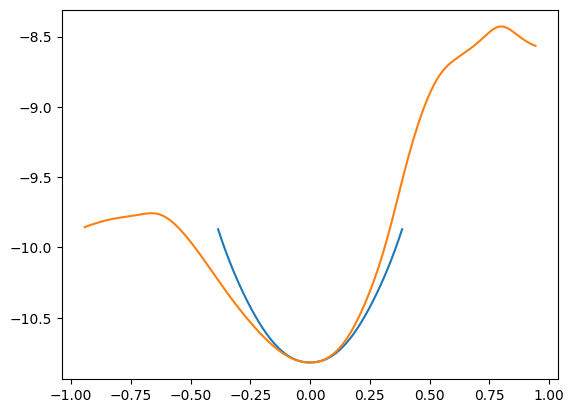

In [28]:
#Check translationally equivariant
from ase import Atom, Atoms
import numpy as np
import matplotlib.pyplot as plt


A = 2.7223*np.array([[1,1,0],[1,0,1],[0,1,1]])
atoms_si = Atoms([Atom('Si', (0, 0, 0)), Atom('Si', (0.25, 0.25, 0.25))], cell = A, pbc=True)

atoms_si.set_tags(np.ones(len(atoms_si)))
atoms_si.calc = calc

atoms_si.set_scaled_positions(np.array([[0,0,0],[0.25, 0.25, 0.25]]))

#"""
en = []
dist = []
for a in np.linspace(-0.1,  0.1, 51):
    atoms_si.set_scaled_positions(np.array([[a,0,0],[0.25, 0.25, 0.25]]))
    e = atoms_si.get_potential_energy()
    en.append(e)
    dist.append(np.sign(a)*np.sqrt(np.sum(np.dot(A, [a,0,0])**2)))
en_111_more = []
dist_111_more = []
for a in np.linspace(-0.1,  0.1, 201):
    atoms_si.set_scaled_positions(np.array([[a,a,a],[0.25, 0.25, 0.25]]))
    e = atoms_si.get_potential_energy()
    en_111_more.append(e)
    dist_111_more.append(np.sign(a)*np.sqrt(np.sum(np.dot(A, [a,a,a])**2)))
plt.plot(dist,en)
plt.plot(dist_111_more,en_111_more)
#plt.ylim([-10.7,-10])
# plt.savefig('inv.png')
# plt.close()
#"""




Melt quench

In [29]:
%%time
import ase,os
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.nvtberendsen import NVTBerendsen
from jarvis.db.figshare import get_jid_data
from jarvis.core.atoms import Atoms, ase_to_atoms
calc = AlignnAtomwiseCalculator(path='OutputDir',device=device, force_mult_batchsize=False)
!rm */*.traj
def ensure_cell_size(ase_atoms, min_size):
    """Ensure that all cell dimensions are at least min_size."""
    cell_lengths = ase_atoms.get_cell().lengths()
    scale_factors = np.ceil(min_size / cell_lengths).astype(int)
    supercell_dims = [max(1, scale) for scale in scale_factors]
    return supercell_dims

calculator = calc
jid = 'JVASP-1002'
atoms=Atoms.from_dict(get_jid_data(jid=jid,dataset='dft_3d')['atoms']).get_conventional_atoms
relaxed_atoms=atoms
ase_atoms = atoms.ase_converter()
dim = ensure_cell_size(ase_atoms, min_size=10.0)
supercell = relaxed_atoms.make_supercell_matrix(dim)
ase_atoms = supercell.ase_converter()
ase_atoms.calc = calculator

dt = 1 * ase.units.fs
temp0, nsteps0 = 3500, 1000
temp1, nsteps1 = 300, 2000
taut = 20 * ase.units.fs
if not os.path.exists("output_melt"):
    os.mkdir("output_melt")
trj = os.path.join("output_melt", f"{jid}_melt.traj")

# Initialize velocities and run the first part of the MD simulation


MaxwellBoltzmannDistribution(ase_atoms, temp0 * ase.units.kB)
dyn = NVTBerendsen(ase_atoms, dt, temp0, taut=taut, trajectory=trj)

def myprint():
    message = f"time={dyn.get_time() / ase.units.fs: 5.0f} fs T={ase_atoms.get_temperature(): 3.0f} K"
    print(message)
dyn.attach(myprint, interval=20)
dyn.run(nsteps0)

# Cool down to room temperature
dyn.set_temperature(temp1)
dyn.run(nsteps1)

# Convert back to JARVIS atoms and save the final structure
final_atoms = ase_to_atoms(ase_atoms)
poscar_filename = os.path.join(
    "output_melt", f"POSCAR_{jid}_quenched_{'alignn'}.vasp"
)
from ase.io import write

write(poscar_filename, final_atoms.ase_converter(), format="vasp")
# self.log(f"MD simulation completed. Final structure saved to {poscar_filename}")
# self.job_info["quenched_atoms"] = final_atoms.to_dict()


rm: cannot remove '*/*.traj': No such file or directory
Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.


/usr/local/lib/python3.12/dist-packages/ase/md/md.py:54: FutureWarning: Specify the temperature in K using the 'temperature_K' argument
  warnings.warn(FutureWarning(w))


time=    0 fs T= 3393 K
time=   20 fs T= 1941 K
time=   40 fs T= 2635 K
time=   60 fs T= 2323 K
time=   80 fs T= 2872 K
time=  100 fs T= 2905 K
time=  120 fs T= 3165 K
time=  140 fs T= 3308 K
time=  160 fs T= 3286 K
time=  180 fs T= 3198 K
time=  200 fs T= 3353 K
time=  220 fs T= 3668 K
time=  240 fs T= 3411 K
time=  260 fs T= 3444 K
time=  280 fs T= 3307 K
time=  300 fs T= 3629 K
time=  320 fs T= 3507 K
time=  340 fs T= 3621 K
time=  360 fs T= 3575 K
time=  380 fs T= 3595 K
time=  400 fs T= 3420 K
time=  420 fs T= 3563 K
time=  440 fs T= 3355 K
time=  460 fs T= 3583 K
time=  480 fs T= 3504 K
time=  500 fs T= 3387 K
time=  520 fs T= 3521 K
time=  540 fs T= 3745 K
time=  560 fs T= 3294 K
time=  580 fs T= 3613 K
time=  600 fs T= 3393 K
time=  620 fs T= 3456 K
time=  640 fs T= 3670 K
time=  660 fs T= 3209 K
time=  680 fs T= 3652 K
time=  700 fs T= 3622 K
time=  720 fs T= 3369 K
time=  740 fs T= 3557 K
time=  760 fs T= 3457 K
time=  780 fs T= 3645 K
time=  800 fs T= 3658 K
time=  820 fs T=

/tmp/ipykernel_5368/2636870775.py:38: FutureWarning: Use `ase.geometry.rdf.get_rdf` instead.
  distribution, distance = Analysis(traj[idx]).get_rdf(rmax=5., nbins=100, return_dists=True)[0]


System
1.0
10.98726 0.0 0.0
0.0 10.98726 0.0
0.0 0.0 10.98726
Si 
64 
direct
0.11236222002953768 0.43726569037594826 0.582129874776318 Si
-0.004417015821596914 0.16503434019419203 0.3596189701792814 Si
0.42851959118932625 0.5180052386135144 -0.2580201407571788 Si
0.48557027662523505 1.05445685625674 0.4572289960058216 Si
0.2244356868501591 0.1043896239248806 -0.003431471983409647 Si
0.9869071029210588 0.3929432646783925 0.3883348023657417 Si
0.8138807486184477 1.0382421897282808 0.3620807054200696 Si
0.43683373834248285 0.274074345801837 0.46138676889364044 Si
-0.22322942904180412 0.5479929963998023 0.746225919408301 Si
-0.0473450990932892 0.40411605945851264 0.7324532521473595 Si
0.2946458900143344 0.46556916150910094 0.12700912284936533 Si
-0.07895822531395541 0.1999781111991486 0.8101919827944016 Si
0.1296549990609401 0.4304198214907524 0.24476814379266693 Si
0.4499370771793939 -0.16197976250922383 0.44254646314987206 Si
0.01248030758477208 -0.03819300417498738 0.290663292101437 Si


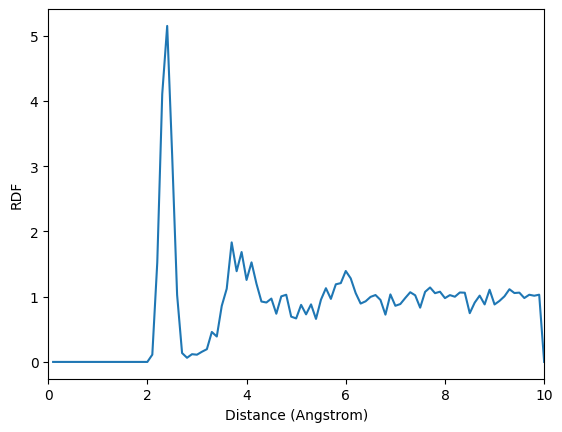

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from jarvis.core.atoms import Atoms
from ase.io.trajectory import Trajectory
from jarvis.core.atoms import ase_to_atoms
from ase.visualize.plot import plot_atoms
from matplotlib.animation import FuncAnimation
from ase.geometry.analysis import Analysis


traj = Trajectory('output_melt/JVASP-1002_melt.traj')


fig, ax = plt.subplots(1, 3, figsize=(9,3), tight_layout=True)

t = np.arange(nsteps0+nsteps1+1) * dt
temp = [atoms.get_temperature() for atoms in traj]

nframes = 20



def update(iframe):
    idx = int((nsteps0+nsteps1)*iframe/nframes)

    ax[0].clear()
    ax[0].set_title('Temperature')
    ax[0].set_xlabel('time (fs)')
    ax[0].set_ylabel('T (K)')
    ax[0].plot(t, temp)
    ax[0].plot(t[idx], temp[idx], marker='X', markersize=10)

    ax[1].clear()
    ax[1].set_title('Structure')
    ax[1].axis('off')
    plot_atoms(traj[idx], ax=ax[1], rotation='45x,45y')

    distribution, distance = Analysis(traj[idx]).get_rdf(rmax=5., nbins=100, return_dists=True)[0]
    ax[2].clear()
    ax[2].set_title('RDF')
    ax[2].set_ylim((0,10))
    ax[2].set_xlabel('distance (A))')
    ax[2].set_ylabel('distribution')
    ax[2].plot(distance, distribution, color='darkblue')
ani = FuncAnimation(fig, update, np.arange(nframes), blit=False, interval=250.)
ani.save('ani_si_2k.gif', writer="imagemagick")
plt.close()

atoms=ase_to_atoms(traj[-1])
print(atoms)
dists=[]
for i in atoms.get_all_neighbors(r=10):
    for j in i:
      dists.append(j[2])
dists=np.array(dists)
hist, bins = np.histogram(dists, bins=np.arange(0.1, 10.2, 0.1))
number_density = atoms.num_atoms / atoms.volume
shell_vol = (
            4.0
            / 3.0
            * np.pi
            * (np.power(bins[1:], 3) - np.power(bins[:-1], 3))
        )
rdf = (
            hist / shell_vol / number_density / atoms.num_atoms
        )
plt.plot(bins[:-1], rdf)
plt.xlim([0,10])
plt.xlabel('Distance (Angstrom)')
plt.ylabel('RDF')
# plt.savefig('rdf.png')
# plt.close()
plt.show()


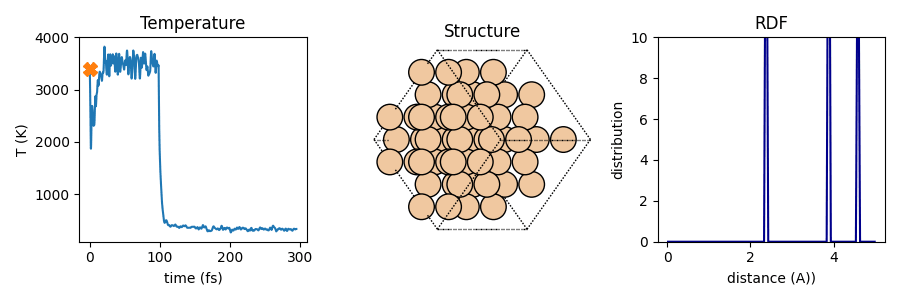

In [31]:
from IPython.display import Image, display

display(Image(filename='ani_si_2k.gif'))


In [32]:
from ase.visualize import view
view(atoms.ase_converter(),viewer='x3d')

In [33]:
atoms.plot_atoms()


Scaling

In [34]:
from ase.build.supercells import make_supercell
import numpy as np
import time
from alignn.ff.ff import AlignnAtomwiseCalculator, default_path, ev_curve
import pandas as pd
import numpy as np
import zipfile
import json
import os
import glob
import matplotlib.pyplot as plt
from ase.stress import full_3x3_to_voigt_6_stress, voigt_6_to_full_3x3_stress
from ase import Atoms,Atom
A = 2.7223*np.array([[1,1,0],[1,0,1],[0,1,1]])
model_path = "OutputDir"
dir_name = model_path
calc = AlignnAtomwiseCalculator(
    path=model_path,
    force_mult_natoms=False,
    stress_wt=0.3,
    device='cuda'
)
atoms_si = Atoms([Atom('Si', (0, 0, 0)), Atom('Si', (0.25, 0.25, 0.25))], cell = A, pbc=True)
atoms_si.calc = calc
en = atoms_si.get_potential_energy()
numbers = np.arange(1,12,1)
times = []
natoms=[]
for i in numbers:

  sc=make_supercell(atoms_si, [[i,0,0],[0,i,0],[0,0,i]])
  t1=time.time()
  sc.calc = calc

  en = sc.get_potential_energy()/len(sc)
  t2=time.time()

  times.append(t2-t1)
  natoms.append(len(sc))
  print(i,len(sc),en,t2-t1)

1 2 [-4.2530904] 0.015974998474121094
2 16 [-4.2530894] 0.016698837280273438
3 54 [-4.253087] 0.01997518539428711
4 128 [-4.2530885] 0.0312960147857666
5 250 [-4.253089] 0.06986212730407715
6 432 [-4.253089] 0.18218016624450684
7 686 [-4.2530866] 0.4424400329589844
8 1024 [-4.253084] 0.9450984001159668
9 1458 [-4.2530932] 1.9100534915924072
10 2000 [-4.253095] 3.536367177963257
11 2662 [-4.253087] 7.287301778793335


Scaling: t ≈ 1.808e-05 · N^1.581
(ideal linear = 1.0, quadratic = 2.0)


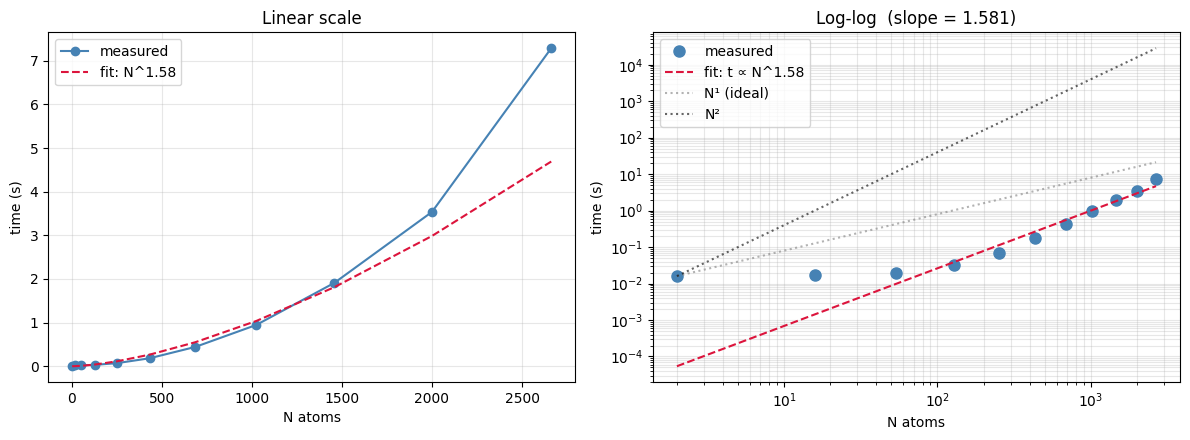


Throughput at N=2662: 365 atoms/s


In [35]:
import numpy as np
import matplotlib.pyplot as plt

natoms = np.array(natoms)
times = np.array(times)

# Fit log(t) = alpha * log(N) + c  →  t = C * N^alpha
# Use only larger systems where overhead is negligible
mask = natoms >= 50
log_n = np.log(natoms[mask])
log_t = np.log(times[mask])
alpha, log_C = np.polyfit(log_n, log_t, 1)
C = np.exp(log_C)

print(f"Scaling: t ≈ {C:.3e} · N^{alpha:.3f}")
print(f"(ideal linear = 1.0, quadratic = 2.0)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Linear scale
axes[0].plot(natoms, times, 'o-', color='steelblue', label='measured')
axes[0].plot(natoms, C * natoms**alpha, '--', color='crimson',
             label=f'fit: N^{alpha:.2f}')
axes[0].set_xlabel('N atoms')
axes[0].set_ylabel('time (s)')
axes[0].set_title('Linear scale')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Log-log
axes[1].loglog(natoms, times, 'o', color='steelblue', markersize=8, label='measured')
n_fit = np.logspace(np.log10(natoms.min()), np.log10(natoms.max()), 100)
axes[1].loglog(n_fit, C * n_fit**alpha, '--', color='crimson',
               label=f'fit: t ∝ N^{alpha:.2f}')
# Reference slopes
axes[1].loglog(n_fit, times[0] * (n_fit/natoms[0])**1.0, ':', color='gray',
               alpha=0.6, label='N¹ (ideal)')
axes[1].loglog(n_fit, times[0] * (n_fit/natoms[0])**2.0, ':', color='black',
               alpha=0.6, label='N²')
axes[1].set_xlabel('N atoms')
axes[1].set_ylabel('time (s)')
axes[1].set_title(f'Log-log  (slope = {alpha:.3f})')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('alignn_scaling.png', dpi=150)
plt.show()

# Also useful: throughput (atoms/sec)
print(f"\nThroughput at N=2662: {natoms[-1]/times[-1]:.0f} atoms/s")

Training analysis

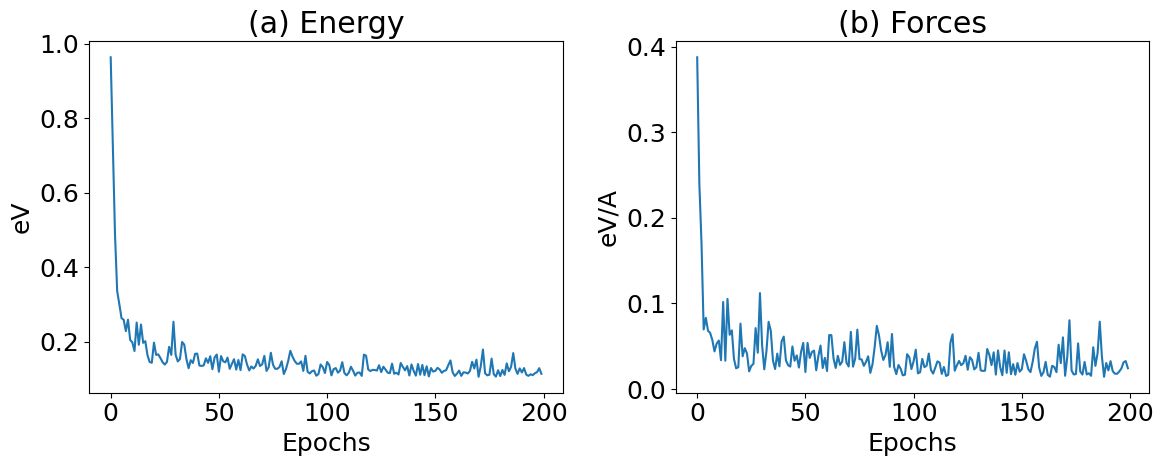

[0.11389904376119375, 0.024293602211400867, 0.0, 0.08960544317960739, 0.0, 0.0]


In [37]:
from jarvis.db.jsonutils import loadjson
from matplotlib.gridspec import GridSpec
import numpy as np
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import os
%matplotlib inline
# Plot training hostory for validation set
dir_name = "OutputDir"
json_path = os.path.join(dir_name, "history_val.json")
v = loadjson(json_path)
ens = []
fs = []
for i in v:
    ens.append(i[0])
    fs.append(i[1])
the_grid = GridSpec(1, 2)
plt.rcParams.update({"font.size": 18})
plt.figure(figsize=(12, 5))
plt.subplot(the_grid[0])
plt.title("(a) Energy")
plt.plot(ens)
plt.xlabel("Epochs")
plt.ylabel("eV")
plt.subplot(the_grid[1])
plt.title("(b) Forces")
plt.plot(fs)
plt.xlabel("Epochs")
plt.ylabel("eV/A")
plt.tight_layout()
plt.show()
# plt.savefig("history.png")
# plt.close()
print(v[-1])

Val
Baseline MAE: eV 0.29931997259457904
MAE eV 0.015465339024861654
Test
Baseline MAE: eV/A 0.574290006651727
MAE eV/A 0.09027264720855302


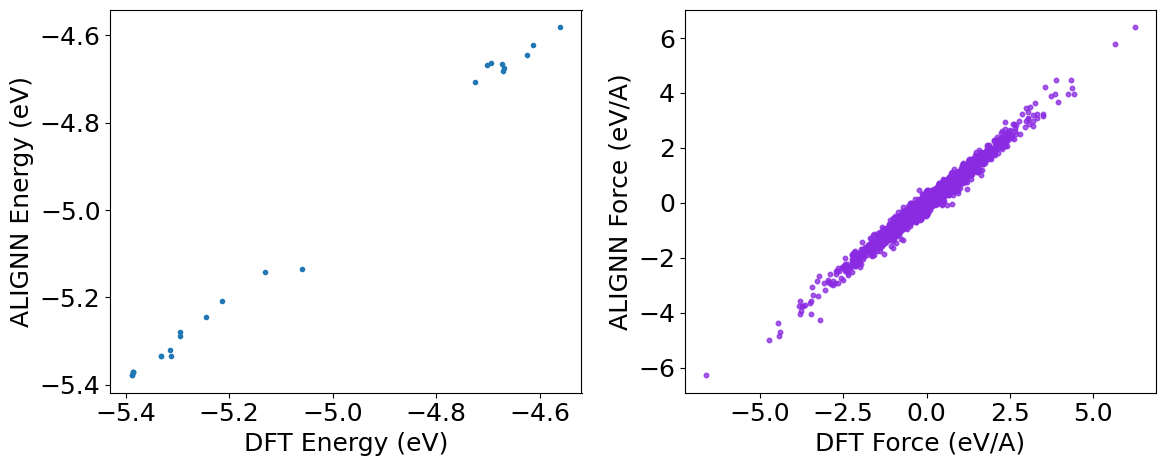

In [38]:
the_grid = GridSpec(1, 2)
json_path = os.path.join(dir_name, "Val_results.json")
test = loadjson(json_path)
plt.rcParams.update({"font.size": 18})
plt.figure(figsize=(12, 5))
plt.subplot(the_grid[0])
xx = []
yy = []
factor = 1
for i in test:
    for j, k in zip(i["target_out"], i["pred_out"]):
        xx.append(j)
        yy.append(k)
xx = np.array(xx) * factor
yy = np.array(yy) * factor

x_bar = np.mean(xx)
baseline_mae = mean_absolute_error(
    np.array(xx),
    np.array([x_bar for i in range(len(xx))]),
)
print("Val")
print("Baseline MAE: eV", baseline_mae)
print("MAE eV", mean_absolute_error(xx, yy))

plt.plot(xx, yy, ".")
plt.ylabel("ALIGNN Energy (eV)")
plt.xlabel("DFT Energy (eV)")
plt.subplot(the_grid[1])
xx = []
yy = []
for i in test:
    for j, k in zip(i["target_grad"], i["pred_grad"]):
        for m, n in zip(j, k):
            xx.append(m)
            yy.append(n)
xx = np.array(xx) * factor
yy = np.array(yy) * factor

x_bar = np.mean(xx)
baseline_mae = mean_absolute_error(
    np.array(xx),
    np.array([x_bar for i in range(len(xx))]),
)
print("Test")
print("Baseline MAE: eV/A", baseline_mae)
print("MAE eV/A", mean_absolute_error(xx, yy))
plt.scatter(xx, yy, c="blueviolet", s=10, alpha=0.5)

plt.scatter(xx, yy, c="blueviolet", s=10, alpha=0.5)
plt.ylabel("ALIGNN Force (eV/A)")
plt.xlabel("DFT Force (eV/A)")
plt.tight_layout()
plt.show()
# plt.savefig("val.png")
# plt.close()


Equation of state

## Phonon bandstructure

In [39]:
# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

In [40]:
!pip install phonopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.6/661.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.7/93.7 kB 11.8 MB/s eta 0:00:00


In [41]:
  import argparse
  import numpy as np
  import plotly.graph_objects as go
  from ase import Atoms as AseAtoms
  from ase.filters import ExpCellFilter
  from ase.optimize import FIRE
  from phonopy import Phonopy
  from phonopy.structure.atoms import PhonopyAtoms

  from jarvis.core.atoms import Atoms, ase_to_atoms
  from jarvis.core.kpoints import Kpoints3D as Kpoints
  from jarvis.db.figshare import get_jid_data

  from alignn.ff.ff import AlignnAtomwiseCalculator


  def relax(atoms: Atoms, calc, fmax=0.05, steps=100):
      a = atoms.ase_converter()
      a.calc = calc
      FIRE(ExpCellFilter(a), logfile=None).run(fmax=fmax, steps=steps)
      return ase_to_atoms(a)


  def compute_phonons(atoms, calc, dim=(2, 2, 2), distance=0.03, line_density=20):
      bulk = PhonopyAtoms(
          symbols=atoms.elements,
          scaled_positions=atoms.frac_coords,
          cell=atoms.lattice_mat,
      )
      ph = Phonopy(bulk, [[dim[0], 0, 0], [0, dim[1], 0], [0, 0, dim[2]]])
      ph.generate_displacements(distance=distance)

      forces_set = []
      # `.supercells_with_displacements` is the modern property;
      # the getter method was removed in newer phonopy versions.
      supercells = ph.supercells_with_displacements
      for sc in supercells:
          a = AseAtoms(
              symbols=list(sc.symbols),
              scaled_positions=np.array(sc.scaled_positions),
              cell=np.array(sc.cell),
              pbc=True,
          )
          a.calc = calc
          F = np.array(a.get_forces())
          F -= F.mean(axis=0)
          forces_set.append(F)
      ph.produce_force_constants(forces=forces_set)

      kp = Kpoints().kpath(atoms, line_density=line_density)
      q_points = np.array(kp.kpts)
      labels_raw = kp.labels

      freqs, distances, tick_pos, tick_labels = [], [], [], []
      last_kstr = None
      d = 0.0
      for i, (q, lbl) in enumerate(zip(q_points, labels_raw)):
          if i > 0:
              d += np.linalg.norm(q_points[i] - q_points[i - 1])
          distances.append(d)
          freqs.append(ph.get_frequencies(q))
          kstr = ",".join(f"{x:.6f}" for x in q)
          if lbl and kstr != last_kstr:
              tick_pos.append(d)
              tick_labels.append(lbl)
              last_kstr = kstr
      #return np.array(distances), np.array(freqs), tick_pos, tick_labels
      return np.array(distances), np.array(freqs), tick_pos, tick_labels, ph


  def plot(distances, freqs, tick_pos, tick_labels, title=""):
      fig = go.Figure()
      for b in range(freqs.shape[1]):
          fig.add_trace(go.Scatter(
              x=distances, y=freqs[:, b], mode="lines",
              line=dict(color="steelblue", width=1.5),
              showlegend=False, hovertemplate="d=%{x:.3f}<br>ν=%{y:.3f} THz",
          ))
      fig.add_hline(y=0, line=dict(color="black", dash="dot", width=1))
      for xp in tick_pos[1:-1]:
          fig.add_vline(x=xp, line=dict(color="lightgray", width=1))
      fig.update_layout(
          title=title, width=800, height=500,
          xaxis=dict(
              title="Wave vector",
              tickmode="array",
              tickvals=tick_pos,
              ticktext=[l.replace("\\Gamma", "Γ") for l in tick_labels],
              showgrid=False, zeroline=False,
          ),
          yaxis=dict(title="Frequency (THz)", gridcolor="lightgray"),
          template="plotly_white",
      )
      return fig


  # ---- run ----
  calc = AlignnAtomwiseCalculator(path="OutputDir", force_mult_batchsize=False)
  jid = "JVASP-1002"
  dim = [2, 2, 2]
  out = "phonons.html"

  d = get_jid_data(jid=jid, dataset="dft_3d")
  atoms = Atoms.from_dict(d["atoms"]).get_conventional_atoms
  print(f"loaded {jid}  {atoms.composition.reduced_formula}  N={atoms.num_atoms}")

  relaxed = relax(atoms, calc)
  prim = relaxed.get_primitive_atoms
  print(f"relaxed → primitive N={prim.num_atoms}")

  distances, freqs, tick_pos, tick_labels,ph = compute_phonons(prim, calc, dim=tuple(dim))
  n_imag = int((freqs < -0.05).sum())
  print(f"bands computed: {freqs.shape[1]}  imag modes (<-0.05 THz): {n_imag}")

  fig = plot(distances, freqs, tick_pos, tick_labels,
             title=f"Phonon bands — {atoms.composition.reduced_formula} ({jid})  supercell {dim}")
  fig.write_html(out)
  fig.show()   # add this in a notebook to display inline
  print(f"wrote {out}")

Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
loaded JVASP-1002  Si  N=8


/tmp/ipykernel_5368/547667973.py:20: DeprecationWarning:

Use FrechetCellFilter for better convergence w.r.t. cell variables.



relaxed → primitive N=2


/tmp/ipykernel_5368/547667973.py:48: DeprecationWarning:

forces parameter of produce_force_constants is deprecated. Use Phonopy.forces setter instead.



bands computed: 6  imag modes (<-0.05 THz): 0


wrote phonons.html


In [42]:
  # --- Harmonic thermal properties (Cv, S, F, ZPE) on a q-mesh ---
  import numpy as np
  import plotly.graph_objects as go
  from plotly.subplots import make_subplots

  ph.run_mesh([20, 20, 20])                       # dense BZ sampling
  ph.run_thermal_properties(t_min=0, t_max=1000, t_step=10)

  td = ph.get_thermal_properties_dict()
  T   = td["temperatures"]            # K
  F   = td["free_energy"]             # kJ/mol  (Helmholtz, per unit cell)
  S   = td["entropy"]                 # J/K/mol
  Cv  = td["heat_capacity"]           # J/K/mol

  # Per-atom normalization (phonopy returns per-unit-cell quantities)
  N = len(ph.primitive)
  Cv_at = Cv / N
  S_at  = S  / N
  F_at  = F  / N

  # Zero-point energy from 0 K free energy (in kJ/mol per primitive cell)
  ZPE = F[0]
  print(f"ZPE per primitive cell: {ZPE:.4f} kJ/mol  ({ZPE*1000/96.485:.4f} eV)")
  print(f"Cv @ 300 K: {Cv_at[np.argmin(abs(T-300))]:.3f} J/K/mol-atom  "
        f"(Dulong-Petit limit: 24.94)")

  # --- Plot ---
  fig = make_subplots(rows=1, cols=3, subplot_titles=("Cv", "Entropy S", "Free energy F"))
  fig.add_trace(go.Scatter(x=T, y=Cv_at, name="Cv"), row=1, col=1)
  fig.add_hline(y=24.94, line=dict(dash="dot", color="gray"), row=1, col=1)   # 3R limit
  fig.add_trace(go.Scatter(x=T, y=S_at,  name="S"),  row=1, col=2)
  fig.add_trace(go.Scatter(x=T, y=F_at,  name="F"),  row=1, col=3)
  fig.update_xaxes(title_text="Temperature (K)")
  fig.update_yaxes(title_text="Cv (J/K/mol-atom)", row=1, col=1)
  fig.update_yaxes(title_text="S (J/K/mol-atom)",  row=1, col=2)
  fig.update_yaxes(title_text="F (kJ/mol-atom)",   row=1, col=3)
  fig.update_layout(template="plotly_white", width=1100, height=400, showlegend=False)
  fig.write_html("thermal.html")
  fig.show()

ZPE per primitive cell: 10.1365 kJ/mol  (105.0576 eV)
Cv @ 300 K: 21.110 J/K/mol-atom  (Dulong-Petit limit: 24.94)


In [43]:
!pip install phono3py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 629.9/629.9 kB 13.4 MB/s eta 0:00:00


You can compare the bandstructure here: https://www.ctcms.nist.gov/~knc6/static/JARVIS-DFT/JVASP-1002.xml#elastic_tensor

In [47]:
"""Lattice thermal conductivity κ(T) and 3-phonon properties from ALIGNN-FF.

Uses phono3py for anharmonic (3rd-order) force constants, then solves the
linearized Boltzmann transport equation under the relaxation-time
approximation (RTA).

WARNING: this is expensive. For Si primitive + 2x2x2 supercell (16 atoms),
phono3py generates ~111 displacements for fc3 + ~1 for fc2 ~~ hundreds
of force evaluations. Allow 10-30 min on a single GPU.

Usage:
    python kappa_plotly.py --model-dir OutputDir --jid JVASP-1002 \\
        --dim 2 2 2 --mesh 11 11 11
"""
from __future__ import annotations
import argparse
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from ase import Atoms as AseAtoms
from ase.filters import ExpCellFilter
from ase.optimize import FIRE
from phono3py import Phono3py
from phonopy.structure.atoms import PhonopyAtoms

from jarvis.core.atoms import Atoms, ase_to_atoms
from jarvis.db.figshare import get_jid_data

from alignn.ff.ff import AlignnAtomwiseCalculator


def relax(atoms, calc, fmax=0.05, steps=100):
    a = atoms.ase_converter()
    a.calc = calc
    FIRE(ExpCellFilter(a), logfile=None).run(fmax=fmax, steps=steps)
    return ase_to_atoms(a)


def forces_on_supercell(sc, calc):
    a = AseAtoms(
        symbols=list(sc.symbols),
        scaled_positions=np.array(sc.scaled_positions),
        cell=np.array(sc.cell),
        pbc=True,
    )
    a.calc = calc
    F = np.array(a.get_forces())
    F -= F.mean(axis=0)
    return F


def run_phono3py(atoms, calc, dim=(2, 2, 2), dim_fc2=None, distance=0.03):
    """Build Phono3py, compute fc3 (and fc2) via ALIGNN-FF."""
    bulk = PhonopyAtoms(
        symbols=atoms.elements,
        scaled_positions=atoms.frac_coords,
        cell=atoms.lattice_mat,
    )
    # fc2 supercell can be larger than fc3 supercell for a better harmonic part
    if dim_fc2 is None:
        dim_fc2 = dim
    ph3 = Phono3py(
        bulk,
        supercell_matrix=[[dim[0], 0, 0], [0, dim[1], 0], [0, 0, dim[2]]],
        phonon_supercell_matrix=[[dim_fc2[0], 0, 0], [0, dim_fc2[1], 0], [0, 0, dim_fc2[2]]],
    )
    ph3.generate_displacements(distance=distance)

    # fc3 supercells
    sc3 = ph3.supercells_with_displacements
    n3 = len(sc3)
    print(f"fc3 displacements: {n3}")
    fset3 = []
    for i, sc in enumerate(sc3):
        if sc is None:                                  # symmetry-reduced skip
            fset3.append(None); continue
        F = forces_on_supercell(sc, calc)
        fset3.append(F)
        if (i + 1) % 10 == 0 or i == n3 - 1:
            print(f"  fc3 {i+1}/{n3}")
    ph3.forces = fset3

    # fc2 supercells (phonon supercells)
    sc2 = ph3.phonon_supercells_with_displacements
    n2 = len(sc2)
    print(f"fc2 displacements: {n2}")
    fset2 = []
    for i, sc in enumerate(sc2):
        if sc is None:
            fset2.append(None); continue
        F = forces_on_supercell(sc, calc)
        fset2.append(F)
    ph3.phonon_forces = fset2

    ph3.produce_fc2(symmetrize_fc2=True)
    ph3.produce_fc3(symmetrize_fc3r=True)
    return ph3


def compute_kappa(ph3, mesh=(11, 11, 11), t_min=100, t_max=1000, t_step=50,
                  boundary_mfp=None):
    """Run RTA thermal conductivity. Returns (T, kappa_xx_yy_zz_xy_xz_yz)."""
    ph3.mesh_numbers = list(mesh)
    ph3.init_phph_interaction()
    temperatures = np.arange(t_min, t_max + 1, t_step)
    ph3.run_thermal_conductivity(
        temperatures=temperatures,
        is_isotope=False,
        boundary_mfp=boundary_mfp,      # µm; None = infinite sample
        write_kappa=False,
    )
    tc = ph3.thermal_conductivity
    T = np.asarray(tc.temperatures)
    kappa = np.asarray(tc.kappa)   # shape (1, nT, 6): xx yy zz yz xz xy
    return T, kappa[0]


def plot_kappa(T, kappa, thermo=None, title=""):
    # trace of kappa = average of diagonal components
    kappa_avg = kappa[:, :3].mean(axis=1)

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Thermal conductivity κ(T)",
                        "Log-log view"),
        horizontal_spacing=0.12,
    )
    for i, lbl in enumerate(["κ_xx", "κ_yy", "κ_zz"]):
        fig.add_trace(go.Scatter(x=T, y=kappa[:, i], mode="lines+markers",
                                 name=lbl, line=dict(width=1.5)),
                      row=1, col=1)
    fig.add_trace(go.Scatter(x=T, y=kappa_avg, mode="lines",
                             name="κ_avg", line=dict(color="black", dash="dash")),
                  row=1, col=1)

    fig.add_trace(go.Scatter(x=T, y=kappa_avg, mode="lines+markers",
                             name="κ_avg (log-log)",
                             line=dict(color="steelblue", width=1.5),
                             showlegend=False),
                  row=1, col=2)
    fig.update_xaxes(type="log", title_text="T (K)", row=1, col=2)
    fig.update_yaxes(type="log", title_text="κ (W/m·K)", row=1, col=2)

    fig.update_xaxes(title_text="T (K)", row=1, col=1)
    fig.update_yaxes(title_text="κ (W/m·K)", row=1, col=1)
    fig.update_layout(template="plotly_white", title=title,
                     width=1100, height=450)
    return fig


def print_summary(T, kappa, name=""):
    kappa_avg = kappa[:, :3].mean(axis=1)
    i300 = int(np.argmin(abs(T - 300)))
    print(f"\n── κ summary {name} ──")
    print(f"κ_xx, κ_yy, κ_zz (300 K) = {kappa[i300,0]:.2f}, "
          f"{kappa[i300,1]:.2f}, {kappa[i300,2]:.2f} W/m·K")
    print(f"κ_avg(300 K) = {kappa_avg[i300]:.2f} W/m·K")
    # T-scaling: fit log(κ) = a - p*log(T) in high-T regime
    hi = T > 300
    if hi.sum() > 2:
        slope = np.polyfit(np.log(T[hi]), np.log(kappa_avg[hi]), 1)[0]
        print(f"high-T exponent p (κ ~ T^-p): p ≈ {-slope:.2f}  "
              f"(3-phonon expects ~1)")



# ap = argparse.ArgumentParser()
# ap.add_argument("--model-dir", default="OutputDir")
# ap.add_argument("--jid", default="JVASP-1002")
# ap.add_argument("--dim", type=int, nargs=3, default=[2, 2, 2],
#                 help="fc3 supercell")
# ap.add_argument("--dim-fc2", type=int, nargs=3, default=None,
#                 help="fc2 supercell (default = fc3 supercell)")
# ap.add_argument("--mesh", type=int, nargs=3, default=[11, 11, 11])
# ap.add_argument("--t-max", type=float, default=1000.0)
# ap.add_argument("--out", default="kappa.html")
# args = ap.parse_args()

calc = AlignnAtomwiseCalculator(path="OutputDir", force_mult_batchsize=False)
jid = "JVASP-1002"
dim = [2,2,2]
out = "phonons.html"
mesh=[11, 11, 11]
t_max=1000.0
out = "kappa.html"
dim_fc2=None
model_dir=  "OutputDir"

# d = get_jid_data(jid=jid, dataset="dft_3d")
# atoms = Atoms.from_dict(d["atoms"]).get_conventional_atoms

calc = AlignnAtomwiseCalculator(path=model_dir, force_mult_batchsize=False)
d = get_jid_data(jid=jid, dataset="dft_3d")
atoms = Atoms.from_dict(d["atoms"]).get_conventional_atoms
formula = atoms.composition.reduced_formula
print(f"loaded {jid}  {formula}  N={atoms.num_atoms}")

relaxed = relax(atoms, calc)
prim = relaxed.get_primitive_atoms
print(f"relaxed → primitive N={prim.num_atoms}")

ph3 = run_phono3py(
    prim, calc,
    dim=tuple(dim),
    dim_fc2=tuple(dim_fc2) if dim_fc2 else None,
)
T, kappa = compute_kappa(ph3, mesh=tuple(mesh), t_max=t_max)
print_summary(T, kappa, formula)

fig = plot_kappa(T, kappa,
                title=f"{formula} ({jid}) — κ(T) via phono3py+ALIGNN-FF "
                      f"[fc3 {dim}, mesh {mesh}]")
fig.write_html(out)
fig.show()
print(f"\nwrote {out}")
# NOTE: Currently underestimated

Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
loaded JVASP-1002  Si  N=8
relaxed → primitive N=2


/tmp/ipykernel_5368/1420088682.py:36: DeprecationWarning:

Use FrechetCellFilter for better convergence w.r.t. cell variables.



fc3 displacements: 57
  fc3 10/57
  fc3 20/57
  fc3 30/57
  fc3 40/57
  fc3 50/57
  fc3 57/57
fc2 displacements: 1

── κ summary Si ──
κ_xx, κ_yy, κ_zz (300 K) = 29.49, 29.49, 29.49 W/m·K
κ_avg(300 K) = 29.49 W/m·K
high-T exponent p (κ ~ T^-p): p ≈ 1.01  (3-phonon expects ~1)



wrote kappa.html


Elastic constants

In [48]:
!pip install -q elastic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.0/627.0 kB 15.1 MB/s eta 0:00:00


In [49]:
from elastic import get_elementary_deformations, get_elastic_tensor
import elastic
import ase
from jarvis.core.atoms import ase_to_atoms
from jarvis.core.atoms import Atoms
from jarvis.db.figshare import get_jid_data

ph_path='OutputDir'
atoms=Atoms.from_dict(get_jid_data(jid='JVASP-1002',dataset='dft_3d')['atoms']).get_conventional_atoms
ase_atoms = atoms.ase_converter()
ase_atoms.calc = calc
systems = get_elementary_deformations(ase_atoms)
cij_order = elastic.elastic.get_cij_order(ase_atoms)
Cij, Bij = get_elastic_tensor(ase_atoms, systems)
for i, j in zip(cij_order, Cij):
    print(i, j / ase.units.GPa)

Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
C_11 5.5073348272863525
C_12 3.557175741007818
C_44 3.278104350112097


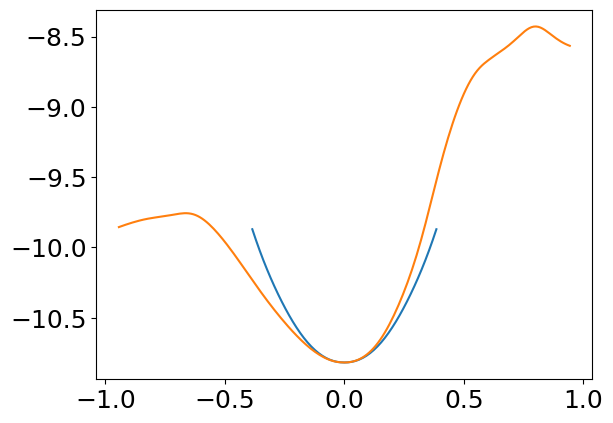

In [50]:
#Check translationally equivariant
from ase import Atom, Atoms
import numpy as np
import matplotlib.pyplot as plt


A = 2.7223*np.array([[1,1,0],[1,0,1],[0,1,1]])
atoms_si = Atoms([Atom('Si', (0, 0, 0)), Atom('Si', (0.25, 0.25, 0.25))], cell = A, pbc=True)

atoms_si.set_tags(np.ones(len(atoms_si)))
atoms_si.calc = calc

atoms_si.set_scaled_positions(np.array([[0,0,0],[0.25, 0.25, 0.25]]))

#"""
en = []
dist = []
for a in np.linspace(-0.1,  0.1, 51):
    atoms_si.set_scaled_positions(np.array([[a,0,0],[0.25, 0.25, 0.25]]))
    e = atoms_si.get_potential_energy()
    en.append(e)
    dist.append(np.sign(a)*np.sqrt(np.sum(np.dot(A, [a,0,0])**2)))
en_111_more = []
dist_111_more = []
for a in np.linspace(-0.1,  0.1, 201):
    atoms_si.set_scaled_positions(np.array([[a,a,a],[0.25, 0.25, 0.25]]))
    e = atoms_si.get_potential_energy()
    en_111_more.append(e)
    dist_111_more.append(np.sign(a)*np.sqrt(np.sum(np.dot(A, [a,a,a])**2)))
plt.plot(dist,en)
plt.plot(dist_111_more,en_111_more)
#plt.ylim([-10.7,-10])
# plt.savefig('kevin.png')
# plt.close()
#"""




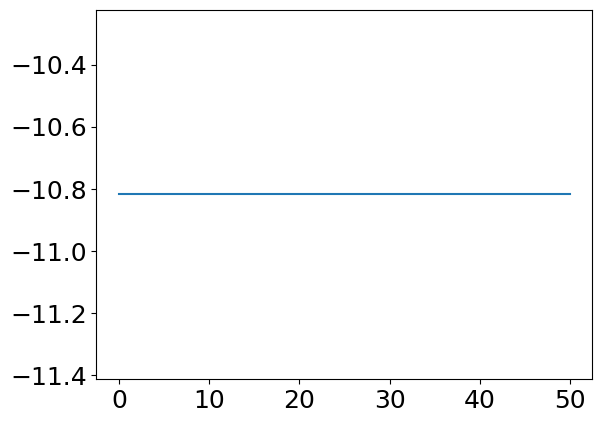

In [51]:
#Check rotationally equivariant
atoms_si = Atoms([Atom('Si', (0, 0, 0)), Atom('Si', (0.25, 0.25, 0.25))], cell = A, pbc=True)
atoms_si.calc = calc
#translations
en_trans = []
for a in np.linspace(-0.1,  0.1, 51):
    atoms_si.set_scaled_positions(np.array([[a,a,a],[a+0.25, a+0.25, a+0.25]]))
    e = atoms_si.get_potential_energy()
    en_trans.append(e)
plt.plot(en_trans)

STOP HERE

Interface design, gamma surface plot

In [ ]:
!pip install -q git+https://github.com/usnistgov/intermat.git@develop

In [ ]:
# Conventional cells
poscar_1= """JVASP1002
1.0
5.49363 0.0 0.0
-0.0 5.49363 0.0
0.0 0.0 5.49363
Si
8
direct
0.25 0.75 0.25 Si
0.0 0.0 0.5 Si
0.25 0.25 0.75 Si
0.0 0.5 0.0 Si
0.75 0.75 0.75 Si
0.5 0.0 0.0 Si
0.75 0.25 0.25 Si
0.5 0.5 0.5 Si
"""

poscar_2 = """JVASP-1174
1.0
5.73163 0.0 0.0
-0.0 5.73163 0.0
0.0 0.0 5.73163
Ga As
4 4
direct
0.0 0.0 0.0 Ga
0.0 0.5 0.5 Ga
0.5 0.0 0.5 Ga
0.5 0.5 0.0 Ga
0.25 0.75 0.75 As
0.25 0.25 0.25 As
0.75 0.75 0.25 As
0.75 0.25 0.75 As
"""


In [ ]:
from jarvis.db.jsonutils import loadjson
from jarvis.core.atoms import Atoms
from jarvis.io.vasp.inputs import Poscar
from intermat.generate import InterfaceCombi
import matplotlib.pyplot as plt

atoms1 = Poscar.from_string(poscar_1).atoms
atoms2 = Poscar.from_string(poscar_1).atoms #Poscar.from_string(poscar_2).atoms

x = InterfaceCombi(
    film_indices=[[1, 1, 0]],
    subs_indices=[[1, 1, 0]],
    vacuum_interface=2,
    film_mats=[atoms1],
    subs_mats=[atoms2],
    disp_intvl=0.0,
    from_conventional_structure_film=False,
    from_conventional_structure_subs=False,
    max_area=300,
    ltol=0.08,

)

structs = x.generate()
heterostructure_atoms=Atoms.from_dict(structs[0]['generated_interface'])
film_atoms=Atoms.from_dict(structs[0]['film_surf'])
surf_atoms=Atoms.from_dict(structs[0]['subs_surf'])


In [ ]:
print(heterostructure_atoms)

Note it can be a high energy if slabs are randomly put together, need xy-plane scan

In [ ]:
from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt
%matplotlib inline
plot_atoms(heterostructure_atoms.ase_converter(),  radii=0.3, rotation=('90x,90y,0z'))
plt.axis('off')


In [ ]:
from jarvis.db.jsonutils import loadjson
from jarvis.core.atoms import Atoms
from jarvis.io.vasp.inputs import Poscar
from intermat.generate import InterfaceCombi
import matplotlib.pyplot as plt

atoms1 = Poscar.from_string(poscar_1).atoms
atoms2 = Poscar.from_string(poscar_1).atoms

# disp_intvl = 0.1 for xy-plane scan
x = InterfaceCombi(
    film_indices=[[1, 1, 0]],
    subs_indices=[[1, 1, 0]],
    vacuum_interface=2,
    film_mats=[atoms1],
    subs_mats=[atoms2],
    disp_intvl=0.1,
    from_conventional_structure_film=False,
    from_conventional_structure_subs=False,
    max_area=300,
    ltol=0.08,

)

structs = x.generate()
extra_params={}
extra_params["alignn_params"] ={}
extra_params["alignn_params"]["model_path"] = dir_name
wads = x.calculate_wad(method='alignn_ff',extra_params=extra_params)
# heterostructure_atoms=Atoms.from_dict(structs[0]['generated_interface'])
# film_atoms=Atoms.from_dict(structs[0]['film_surf'])
# surf_atoms=Atoms.from_dict(structs[0]['subs_surf'])


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
X = x.X
Y = x.Y
wads = np.array(wads).reshape(len(X), len(Y))
wads = np.array(x.wads["wads"])
index = np.argmin(wads)
combined_atoms = Atoms.from_dict(
    x.generated_interfaces[index]["generated_interface"]
)
wads = np.array(wads).reshape(len(X), len(Y))
plt.contourf(wads,cmap='plasma')


In [ ]:
print(combined_atoms)

In [ ]:
# After xy plane scan we can see the diamond structure pattern continues,
# which is desirable for getting low energy structure
from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt
%matplotlib inline
plot_atoms(combined_atoms.ase_converter(),  radii=0.3, rotation=('90x,90y,0z'))
plt.axis('off')


In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(z=wads)])

# fig = go.Figure(data=[go.Contour(z=res['wads'])])
#fig.write_html("file2.html")
fig.show()

General optimization from POSCAR

In [ ]:
from jarvis.io.vasp.inputs import Poscar
from ase.constraints import ExpCellFilter
from ase.optimize.fire import FIRE

def general_relaxer(atoms="", calculator="", fmax=0.05, steps=150,relax=True):
    ase_atoms = atoms.ase_converter()
    ase_atoms.calc = calculator
    if not relax:
         return ase_atoms.get_potential_energy()

    ase_atoms = ExpCellFilter(ase_atoms)

    dyn = FIRE(ase_atoms)
    dyn.run(fmax=fmax, steps=steps)
    return ase_to_atoms(ase_atoms.atoms)

pos="""Si2
1.0
3.3641499856336465 -2.5027128e-09 1.94229273881412
1.121382991333525 3.1717517190189715 1.9422927388141193
-2.5909987e-09 -1.8321133e-09 3.884586486670313
Si
2
Cartesian
3.92483875 2.77528125 6.7980237500000005
0.56069125 0.39646875 0.9711462500000001
"""
s = Poscar.from_string(pos).atoms.get_conventional_atoms
opt = general_relaxer(atoms=s,calculator=calc)
print(s)
print()
print(opt)

Scaling

In [ ]:
from ase.build.supercells import make_supercell
import numpy as np
import time
from alignn.ff.ff import AlignnAtomwiseCalculator, default_path, ev_curve
import pandas as pd
import numpy as np
import zipfile
import json
import os
import glob
import matplotlib.pyplot as plt
from ase.stress import full_3x3_to_voigt_6_stress, voigt_6_to_full_3x3_stress
from ase import Atoms,Atom
A = 2.7223*np.array([[1,1,0],[1,0,1],[0,1,1]])
model_path = "OutputDir"
dir_name = model_path
calc = AlignnAtomwiseCalculator(
    path=model_path,
    force_mult_natoms=False,
    force_multiplier=my_config['batch_size'],
    stress_wt=0.3,
)
atoms_si = Atoms([Atom('Si', (0, 0, 0)), Atom('Si', (0.25, 0.25, 0.25))], cell = A, pbc=True)
atoms_si.calc = calc
en = atoms_si.get_potential_energy()
numbers = np.arange(1,9,1)
times = []
natoms=[]
for i in numbers:

  sc=make_supercell(atoms_si, [[i,0,0],[0,i,0],[0,0,i]])
  t1=time.time()
  sc.calc = calc

  en = sc.get_potential_energy()/len(sc)
  t2=time.time()

  times.append(t2-t1)
  natoms.append(len(sc))
  print(i,len(sc),en,t2-t1)

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(natoms,times,'o-')
plt.xlabel('Number of atoms')
plt.ylabel('Time (s)')
plt.show()

In [ ]:
!conda env export > environment.yml

In [ ]:
!pip freeze

In [ ]:
!conda env export